### Etapa I: Caracterizaci´on Estoc´astica y Frecuencial

In [1]:
import numpy as np
from scipy.io import wavfile
from IPython.display import Audio, display
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import firwin, cheby2, freqz, sosfilt, iirfilter, spectrogram, welch, freqz_zpk, kaiserord, cheb2ord, lfilter, butter, filtfilt


In [ ]:
sr, complete_signal = wavfile.read("data/signal.wav")
complete_signal = complete_signal[:, 0] 

# complete_signal = complete_signal / max(complete_signal)

In [3]:
print(f"Frecuencia de muestreo: {sr}")

Frecuencia de muestreo: 48000


■ Visualizaci´on y Potencia: Graficar las se˜nales en el dominio temporal y esti-
mar su Densidad Espectral de Potencia (PSD) utilizando estimadores espectrales.
A partir de esto, se debe determinar la potencia total de la se˜nal e identificar
cu´ales son las bandas de frecuencia espec´ıficas que concentran la mayor cantidad
de energ´ıa.

Text(0.5, 0, 'muestras')

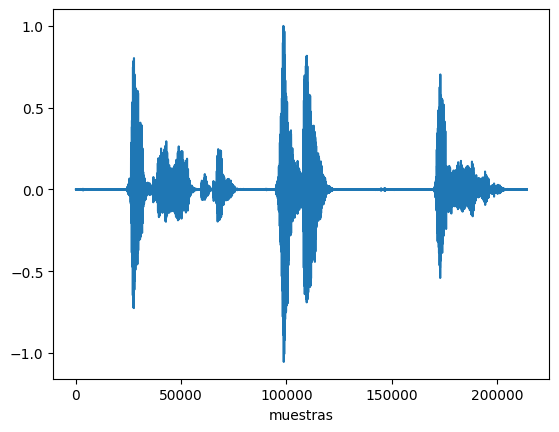

In [4]:
dur = len(complete_signal) / sr
t = np.linspace(0, dur, len(complete_signal))

sns.lineplot(complete_signal)
plt.xlabel("muestras")


Text(0.5, 1.0, 'Densidad Espectral de Potencia')

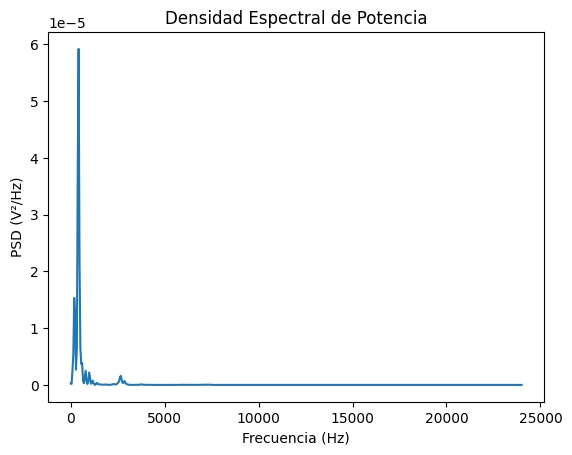

In [5]:
f, psd = welch(complete_signal, fs=sr, nperseg=1024)

plt.plot(f, psd)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD (V²/Hz)")
plt.title("Densidad Espectral de Potencia")

Vamos a "hacer zoom" hasta 5000Hz

Text(0.5, 1.0, 'Densidad Espectral de Potencia')

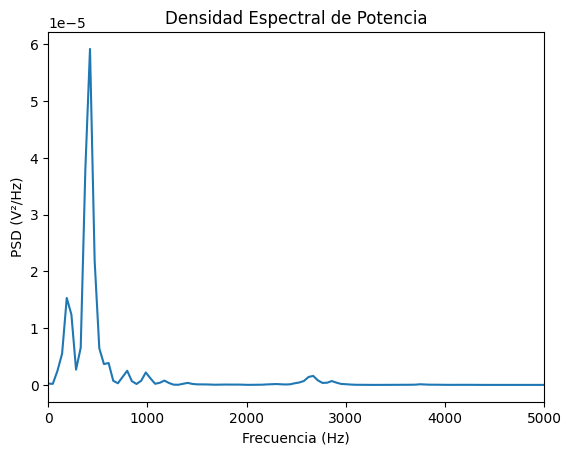

In [6]:
plt.plot(f, psd)
plt.xlim(0,5000)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD (V²/Hz)")
plt.title("Densidad Espectral de Potencia")

In [7]:
potencia = np.mean(complete_signal**2)

print(f"Potencia de la señal: {potencia:.2f}W")

Potencia de la señal: 0.01W


Text(0.5, 1.0, 'Espectrograma')

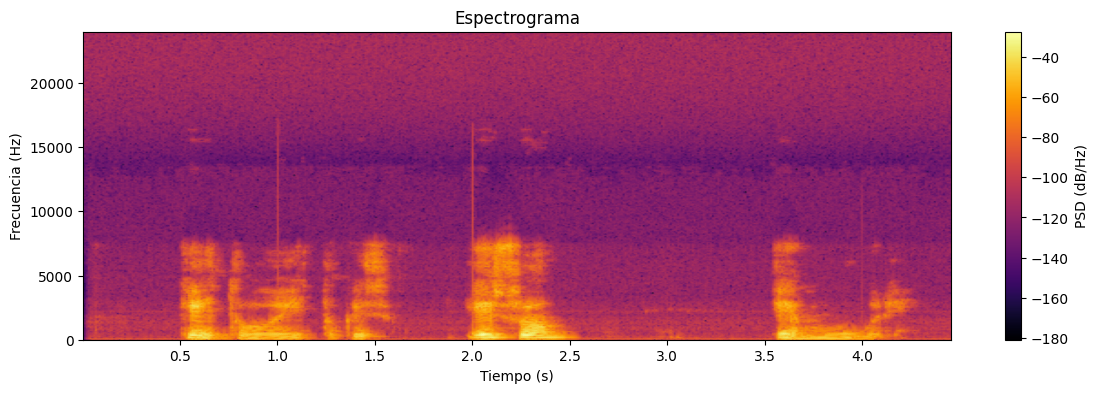

In [8]:
f, t, Sxx = spectrogram(complete_signal, fs=sr, nperseg=512)

plt.figure(figsize=(14, 4))
plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud', cmap='inferno')
plt.ylabel("Frecuencia (Hz)")
plt.xlabel("Tiempo (s)")
plt.colorbar(label="PSD (dB/Hz)")
plt.title("Espectrograma")

Como es de esperar, al tratarse de una señal de voz, la energía se concetra en las frecuencias bajas

 Estacionariedad: Justificar de forma te´orica y pr´actica si las se˜nales asignadas
pueden considerarse Estacionarias en Sentido Amplio (WSS, Wide-Sense Statio-
nary) y erg´odicas en toda su extensi´on, o si por el contrario deben ser analizadas
por tramos o bloques (ventanas). En caso de optar por un an´alisis segmentado, se
deber´a definir y justificar rigurosamente la duraci´on ´optima de dicha ventana.

<Axes: >

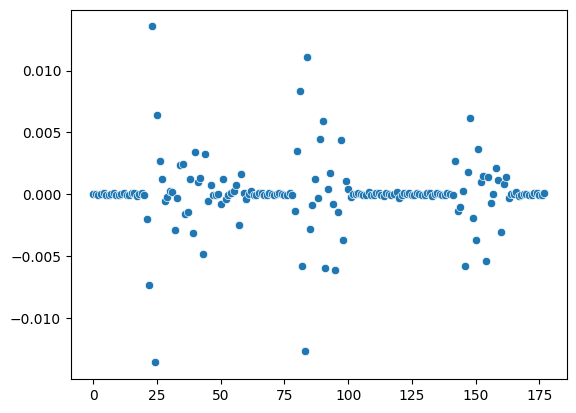

In [9]:
#Tomamos ventanas de 25ms
window_size = int(0.025 * sr)
step = window_size

medias = []

for i in range(0, len(complete_signal) - window_size, step):
    ventana = complete_signal[i:i+window_size]
    medias.append(np.mean(ventana))
    
sns.scatterplot(medias)

**No es WSS y, por ende, no es ergódica**

**Entonces, vamos a trabajar en ventanas de 20-30 ms donde podemos asumir estacionaria a la señal, esto debido a que el tracto vocal tiene una tasa de cambio de alrededor de 50-100 ms**

■ C´alculo de Entrop´ıa: Calcular la entrop´ıa de la se˜nal original para cuantificar
su contenido de informaci´on y grado de aleatoriedad. Para este c´alculo, el grupo
deber´a implementar y comparar dos metodolog´ıas: una basada en el histograma
temporal de amplitudes y otra calculada a partir de la distribuci´on del espectro de
potencia.

**Histograma temporal de amplitudes: La idea es sencilla, partimos las amplitudes en bins y contamos cuántas muestras caen en cada uno. De esta forma podemos pasar a tener probabilidades discretas y usar Shannon**

In [10]:
counts, _ = np.histogram(complete_signal, bins=64)
probs = counts / counts.sum()
probs = probs[probs > 0]  # evitar log(0)
H_amplitud = -np.sum(probs * np.log2(probs))

print(f"Entropía (calculada por amplitud): {H_amplitud:.2f} bits")

Entropía (calculada por amplitud): 2.25 bits


In [11]:
f, psd = welch(complete_signal, fs=sr, nperseg=1024)
psd_norm = psd / psd.sum()
psd_norm = psd_norm[psd_norm > 0]
H_espectral = -np.sum(psd_norm * np.log2(psd_norm))

print(f"Entropía (calculada por densidad espectral): {H_espectral:.2f} bits")

Entropía (calculada por densidad espectral): 3.65 bits


**Entonces, tenemos la información más "concentrada" en el tiempo que en frecuencia. Tiene sentido, viendo la señal y los 3 picos que presenta**

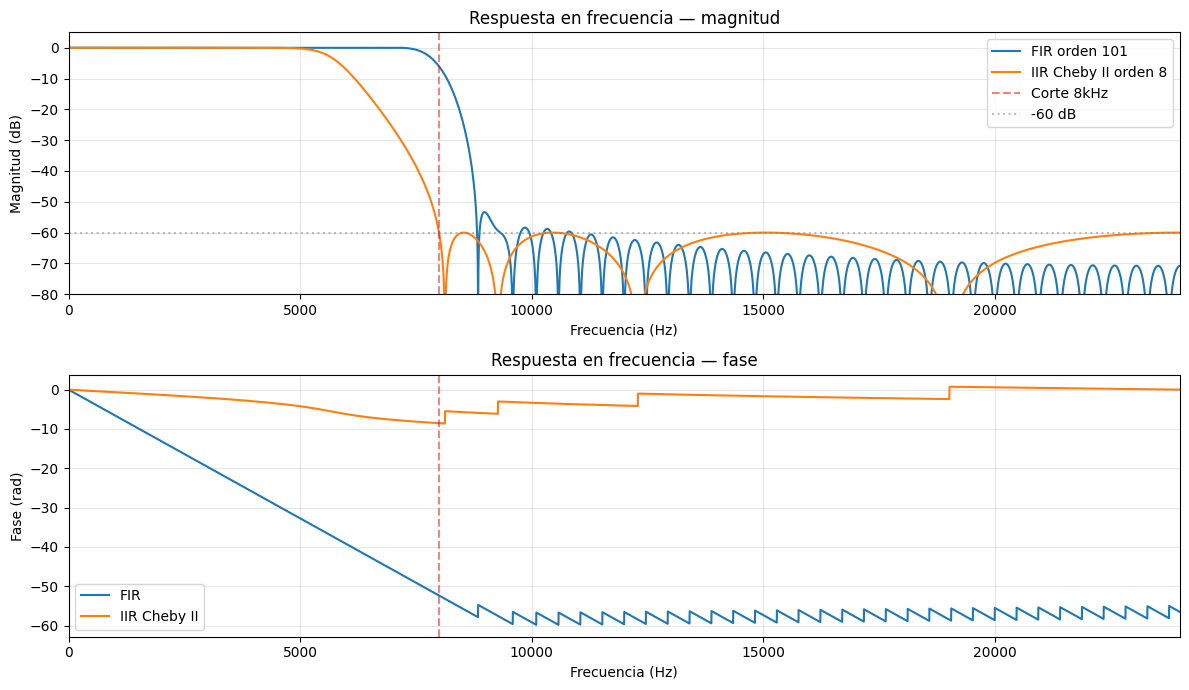

In [12]:

# Frecuencia de Nyquist
nyq = sr / 2
cutoff = 8000  # Hz

# --- FIR por ventanas (firwin) ---
order_fir = 101  # orden impar para filtro tipo I
b_fir = firwin(order_fir, cutoff / nyq, window='hamming')

# --- IIR Chebyshev tipo II ---
order_iir = 8
rs = 60  # atenuación en banda de rechazo (dB)
sos = cheby2(order_iir, rs, cutoff / nyq, btype='low', output='sos')

# --- Respuesta en frecuencia ---
w_fir, h_fir = freqz(b_fir, worN=8192)
w_iir, h_iir = freqz_zpk(*cheby2(order_iir, rs, cutoff / nyq, output='zpk'), worN=8192)

freqs_fir = w_fir * sr / (2 * np.pi)
freqs_iir = w_iir * sr / (2 * np.pi)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Magnitud
axes[0].plot(freqs_fir, 20 * np.log10(np.abs(h_fir) + 1e-10), label=f'FIR orden {order_fir}')
axes[0].plot(freqs_iir, 20 * np.log10(np.abs(h_iir) + 1e-10), label=f'IIR Cheby II orden {order_iir}')
axes[0].axvline(cutoff, color='r', linestyle='--', alpha=0.5, label='Corte 8kHz')
axes[0].axhline(-rs, color='gray', linestyle=':', alpha=0.5, label=f'-{rs} dB')
axes[0].set_xlim(0, nyq)
axes[0].set_ylim(-80, 5)
axes[0].set_xlabel("Frecuencia (Hz)")
axes[0].set_ylabel("Magnitud (dB)")
axes[0].set_title("Respuesta en frecuencia — magnitud")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Fase
axes[1].plot(freqs_fir, np.unwrap(np.angle(h_fir)), label='FIR')
axes[1].plot(freqs_iir, np.unwrap(np.angle(h_iir)), label='IIR Cheby II')
axes[1].axvline(cutoff, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlim(0, nyq)
axes[1].set_xlabel("Frecuencia (Hz)")
axes[1].set_ylabel("Fase (rad)")
axes[1].set_title("Respuesta en frecuencia — fase")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Aplicar filtros ---
signal_fir = np.convolve(complete_signal, b_fir, mode='same')
signal_iir = sosfilt(sos, complete_signal)

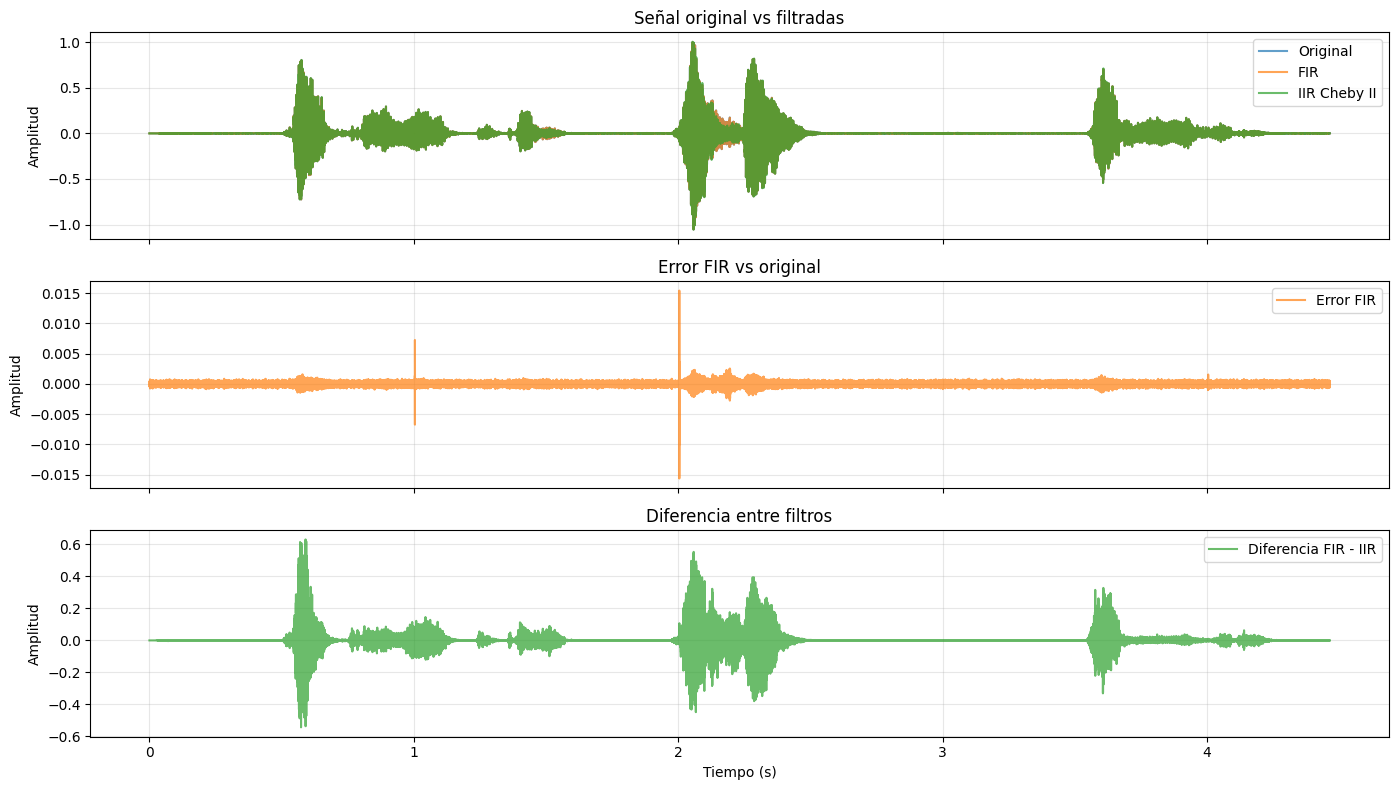

In [13]:
error = signal_fir - signal_iir

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

t = np.linspace(0, len(complete_signal) / sr, len(complete_signal))

axes[0].plot(t, complete_signal, alpha=0.7, label='Original')
axes[0].plot(t, signal_fir, alpha=0.7, label='FIR')
axes[0].plot(t, signal_iir, alpha=0.7, label='IIR Cheby II')
axes[0].set_ylabel("Amplitud")
axes[0].set_title("Señal original vs filtradas")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, signal_fir - complete_signal, color='C1', alpha=0.7, label='Error FIR')
axes[1].set_ylabel("Amplitud")
axes[1].set_title("Error FIR vs original")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(t, error, color='C2', alpha=0.7, label='Diferencia FIR - IIR')
axes[2].set_ylabel("Amplitud")
axes[2].set_xlabel("Tiempo (s)")
axes[2].set_title("Diferencia entre filtros")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Ahora, buscamos los ordenes optimos de los filtros

In [14]:
delta_f = 1000  # ancho de banda de transición en Hz
atten_db = 60   # atenuación deseada en dB

N, beta = kaiserord(atten_db, delta_f / nyq)
print(f"Orden FIR óptimo: {N}")

b_fir = firwin(N, cutoff / nyq, window=('kaiser', beta))

Orden FIR óptimo: 176


In [15]:
wp = 8000 / nyq   # frecuencia de paso (normalizada)
ws = 9000 / nyq   # frecuencia de rechazo (normalizada)
gpass = 3         # rizado máximo en banda de paso (dB)
gstop = 60        # atenuación mínima en banda de rechazo (dB)

N, wn = cheb2ord(wp, ws, gpass, gstop)
print(f"Orden IIR óptimo: {N}")

sos = cheby2(N, gstop, wn, btype='low', output='sos')

Orden IIR óptimo: 14


**En principio, vamos a trabajar con el FIR debido a las practicidades ya conocidas: estabilidad y fase lineal. Sin embargo, no dejamos de tener en cuenta que tiene unas 12 veces más parámetros que el IIR, por lo que si llegara a resultar impráctico por el costo computacional, implementaríamos el IIR.**

2.3. Etapa III: Modelado y Compresi´on mediante Predicci´on Lineal
(LPC)
Para optimizar la transmisi´on de la se˜nal de voz a trav´es del canal, el sistema no
enviar´a la se˜nal muestreada de manera directa, sino los par´ametros estimados de un
modelo matem´atico que permita reconstruirla (sintetizarla) fielmente en el receptor. A
tal fin, se dise˜nar´a un codificador/decodificador basado en el modelo cl´asico fuente-filtro.
Los alumnos deber´an definir, analizar y justificar en su informe t´ecnico los siguientes
n´ucleos tem´aticos:

2.3.1. Intervalo de Ventaneo (An´alisis de Estacionariedad)
Due to que las caracter´ısticas fon´eticas de la voz cambian continuamente en el tiempo,
los coeficientes del filtro predictor son variantes temporales. El grupo de trabajo deber´a
determinar:
■ ¿Cada cu´antos milisegundos (ms) se deben recalcular los coeficientes LPC?
■ Justificar la elecci´on del tama˜no de la ventana en funci´on de la constante de tiempo
que tarda el tracto vocal humano en cambiar su configuraci´on anat´omica (propie-
dad de cuasi-estacionariedad).

**Vamos a tomar ventanas de 30ms, donde podemos asumir estacionaria a la señal de voz. Esto es importante ya que es una de las hipótesis más fuertes que vimos para el cálculo de los coeficientes LPC**

■ Definir qu´e tipo de ventana anal´ıtica (por ejemplo, Hamming, Hanning o Rec-
tangular) es la m´as adecuada para mitigar el efecto de spectral leakage (p´erdida
espectral) durante el c´alculo de la funci´on de autocorrelaci´on.

**Vamos a usar ventanas de Hamming, por tener un buen balance entre el ancho del lobulo central y los lobulos laterales, ya que queremos evitar el spectral leakeage en los armónicos de la frecuencia fundamental.**

2.3.2. Clasificaci´on de la Se˜nal Generadora (Excitaci´on)
Para cada tramo indexado de la se˜nal de voz, el sistema debe decidir de manera
autom´atica (ya sea mediante algoritmos l´ogicos o mediante un umbral emp´ırico basado
en el nivel de energ´ıa y la tasa de cruces por cero) qu´e tipo de sonido se est´a procesando:
■ Fonemas Sonoros (Voiced ): Correspondientes a las vocales (A, E, O, etc.).
El grupo deber´a definir cu´al es la se˜nal generadora adecuada para este escenario
(frecuencia fundamental o pitch provocado por la vibraci´on de las cuerdas locales)
y describir c´omo estimar con precisi´on dicho per´ıodo de repetici´on T0.
■ Fonemas Sordos (Unvoiced ): Correspondientes a consonantes fricativas (S, F,
P, etc.). El grupo deber´a definir qu´e tipo de proceso estoc´astico o se˜nal generadora
modela adecuadamente el paso del aire turbulento a trav´es del tracto vocal sin
vibraci´on de las cuerdas.

**Vamos a buscar los umbrales**

In [16]:
def autocorrelacion(ventana,orden):
    N = len(ventana)
    r = np.zeros(N+N-1)

    for n in range(N+N-1):
        lag = n - (N - 1)
        for k in range(N):
            indice_desplazado = k + lag
            if 0 <= indice_desplazado < N:
                r[n] += ventana[k] * ventana[indice_desplazado]

    limite = orden + 1
    centro = len(ventana) - 1

    # tomamos lo que necesitamos, del medio hasta el la cantidad del orden + 1 y normalizamos por N
    r_cortada = r[centro : centro + limite] / N
    return r_cortada


def levinson_durbin(r, p):
    a = np.zeros((p + 1, p + 1))
    k = np.zeros(p + 1)
    E = np.zeros(p + 1)

    E[0] = r[0]

    for i in range(1, p + 1):

      # 1 <= i <= p
      suma = 0
      for j in range(1, i):
          suma += a[j, i-1] * r[i-j]

      k[i] = - (r[i] + suma) / E[i-1]

      # 2
      a[i, i] = k[i]

      # 3 para 1 <= j <= i-1
      for j in range(1, i):
          a[j, i] = a[j, i-1] + k[i] * a[i-j, i-1]

      # 4
      E[i] = E[i-1] * (1 - k[i]**2)

    coeficientes_finales = a[1:, p]

    return coeficientes_finales, E, a

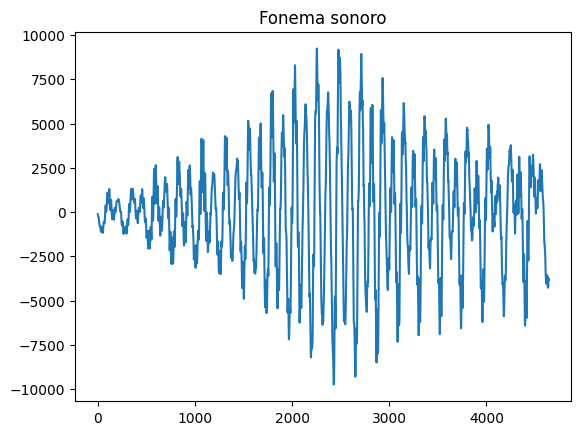

energia_sonoro: 16.131193451098664
zcr_sonoro: 0.02671837965955613


In [17]:
sr, fonema_sonoro = wavfile.read("data/fonema-sonoro-dipe.wav")
fonema_sonoro = fonema_sonoro[:, 0]

energia_sonoro = np.mean(fonema_sonoro**2)
zcr_sonoro = np.mean(np.abs(np.diff(np.sign(fonema_sonoro))) / 2)

sns.lineplot(fonema_sonoro)
plt.title("Fonema sonoro")
plt.show()

print(f"energia_sonoro: {energia_sonoro}")
print(f"zcr_sonoro: {zcr_sonoro}")

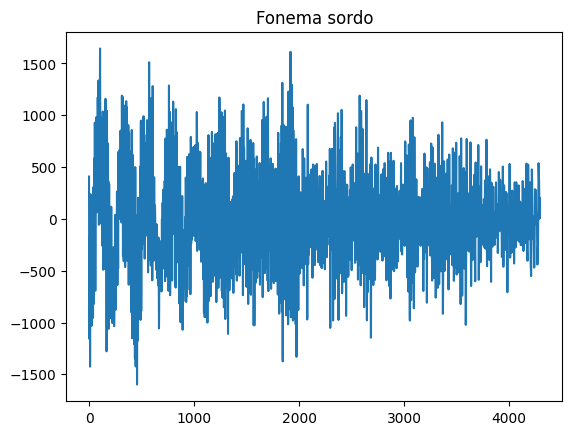

energia_sordo: 2296.30607966457
zcr_sordo: 0.19757688723205966


In [18]:
sr, fonema_sordo = wavfile.read("data/fonema-sordo-dipe.wav")
fonema_sordo = fonema_sordo[:, 0]

energia_sordo = np.mean(fonema_sordo**2)
zcr_sordo = np.mean(np.abs(np.diff(np.sign(fonema_sordo))) / 2)

sns.lineplot(fonema_sordo)
plt.title("Fonema sordo")
plt.show()

print(f"energia_sordo: {energia_sordo}")
print(f"zcr_sordo: {zcr_sordo}")

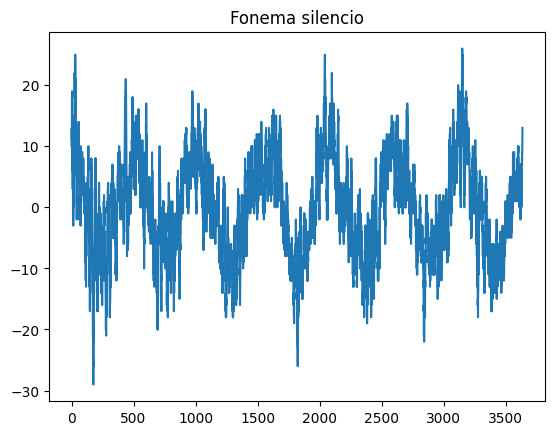

energia_silencio: 66.19312242090784
zcr_silencio: 0.16070445789763346


In [19]:
sr, silencio = wavfile.read("data/silencio-dipe.wav")
silencio = silencio[:, 0]

energia_silencio = np.mean(silencio**2)
zcr_silencio = np.mean(np.abs(np.diff(np.sign(silencio))) / 2)

sns.lineplot(silencio)
plt.title("Fonema silencio")
plt.show()

print(f"energia_silencio: {energia_silencio}")
print(f"zcr_silencio: {zcr_silencio}")

In [20]:
sr, fonema_sonoro = wavfile.read("data/fonema-sonoro-dipe.wav")
fonema_sonoro = fonema_sonoro[:, 0]

energia_sonoro = np.mean(fonema_sonoro**2)
zcr_sonoro = np.mean(np.abs(np.diff(np.sign(fonema_sonoro))) / 2)

In [21]:
#Umbrales hardcodeados
def clasificar_frame(ventana):
    energia = np.mean(ventana**2)
    zcr = np.mean(np.abs(np.diff(np.sign(ventana))) / 2)
    
    if energia < 100 and zcr < 0.05:
        return 'sonoro'
    elif energia < 200:
        return 'silencio'
    else:
        return 'sordo'

In [22]:
def obtener_T0(ventana):
    f0_min, f0_max = 100, 300
    lag_min = int(sr / f0_max)
    lag_max = int(sr / f0_min)
    
    cep = np.fft.ifft(np.log(np.abs(np.fft.fft(ventana))+ 1e-10)).real
    lag_pico = np.argmax(cep[lag_min:lag_max]) + lag_min
    T0 = lag_pico / sr
    
    return T0

In [23]:
p_max = 100

In [24]:
def procesar_ventana_lpc(ventana, sr, p_max=14):
    """
    Recibe una única ventana, la clasifica, calcula su LPC óptimo (Akaike)
    y devuelve un Frame de tamaño fijo = [a1, a2, ..., ap_max, G, Bs/s, T0].
    """
    N = len(ventana)
    
    # 1. Clasificación (Antes de ventanear)
    clase = clasificar_frame(ventana)
    
    # 2. Definir parámetros de excitación
    if clase == 'sonoro':
        Bs_s = 1
        T0 = obtener_T0(ventana)
    else: # Sordo o silencio
        Bs_s = 0
        T0 = 0.0
        
    # 3. Aplicar ventana analítica (Hamming)
    ventana_hamming = np.hamming(N)
    tramo_ventaneado = ventana * ventana_hamming
    
    # 4. Cálculo de Coeficientes Predictivos (LPC)
    r = autocorrelacion(tramo_ventaneado, p_max)
    
    if clase == 'silencio':
        # Si es silencio absoluto
        coef_optimos_completos = np.zeros(p_max)
        G = 0.0
    else:
        coefs, E_array, matriz_A = levinson_durbin(r, p_max)
        
        # Optimización con Criterio de Akaike
        p_array = np.arange(p_max + 1)
        E_seguro = np.maximum(E_array, 1e-10) 
        I_p = np.log(E_seguro) + (2 * p_array) / N
        
        # Buscamos el orden óptimo excluyendo el orden 0
        orden_optimo = np.argmin(I_p[1:]) + 1
        
        # Extraemos solo los coeficientes útiles
        coef_optimos = matriz_A[1:orden_optimo+1, orden_optimo]
        G = np.sqrt(abs(E_array[orden_optimo]))
        
        # RELLENO CON CEROS (Zero-padding) para mantener el Frame de tamaño constante
        coef_optimos_completos = np.zeros(p_max)
        coef_optimos_completos[:orden_optimo] = coef_optimos
        
    # 5. Estructura del Frame de Transmisión
    # Frame = [a1, a2, ..., ap_max, G, Bs/s, T0]
    frame_actual = list(coef_optimos_completos) + [G, Bs_s, T0]
    
    return frame_actual

In [25]:
window_size = int(0.030 * sr)
frames_transmitidos = []

senal_normalizada = complete_signal

# Bucle principal que hace de "Transmisor"
for i in range(0, len(senal_normalizada) - window_size, window_size):
    tramo = senal_normalizada[i : i + window_size]
    
    # Le pasamos la pelota a tu nueva función
    frame = procesar_ventana_lpc(tramo, sr, p_max=p_max)
    
    frames_transmitidos.append(frame)

# Matriz final lista para usar en el receptor o en la Etapa V
matriz_transmision = np.array(frames_transmitidos)

**Probemos si reconstruye la señal**

In [26]:
def reconstruir_senal(matriz_transmision, sr, window_size, p_max=14):
    señal_reconstruida = []
    
    for frame in matriz_transmision:
        coefs = frame[:p_max]
        G     = frame[p_max]
        Bs_s  = int(frame[p_max + 1])
        T0    = frame[p_max + 2]
        
        N = window_size
        x = np.zeros(N)
        
        if Bs_s == 1 and T0 > 0:
            # Sonoro: tren de impulsos con T0 estimado por cepstrum
            periodo_muestras = max(1, int(T0 * sr))
            x[::periodo_muestras] = 1.0
        elif Bs_s == 0 and G > 0:
            # Sordo: ruido blanco
            x = np.random.default_rng().normal(0, 1, N)
        # Silencio: x queda en ceros
        
        # G en el numerador, igual que la referencia
        denominador = np.concatenate([[1.0], coefs])
        tramo = lfilter([G], denominador, x)
        
        señal_reconstruida.append(tramo)
    
    return np.concatenate(señal_reconstruida)


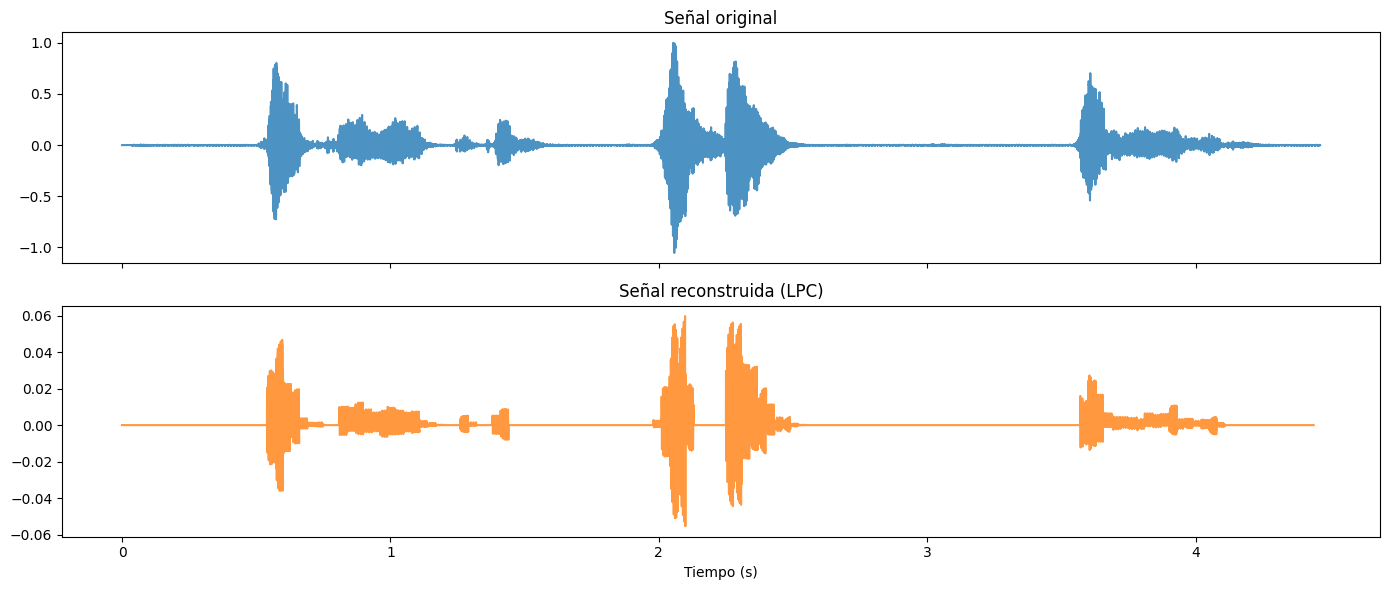

In [27]:

senal_reconstruida = reconstruir_senal(matriz_transmision, sr, window_size, p_max=p_max)

# Escuchar
from IPython.display import Audio, display
display(Audio(senal_reconstruida, rate=sr))

# Comparar
t_orig  = np.linspace(0, len(complete_signal) / sr, len(complete_signal))
t_recon = np.linspace(0, len(senal_reconstruida) / sr, len(senal_reconstruida))

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(t_orig, complete_signal, alpha=0.8)
axes[0].set_title("Señal original")
axes[1].plot(t_recon, senal_reconstruida, color='C1', alpha=0.8)
axes[1].set_title("Señal reconstruida (LPC)")
axes[1].set_xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()

■ An´alisis de Informaci´on: Calcular la entrop´ıa del residuo de predicci´on lineal
y compararla anal´ıticamente con la entrop´ıa de la se˜nal original. Explicar razona-
damente qu´e sucedi´o con la informaci´on ´util y con la redundancia intr´ınseca de la
se˜nal.

In [28]:
#Armamos el residuo
residuos = []
window_size = int(0.025 * sr)

for idx, frame in enumerate(matriz_transmision):
    coefs = frame[:p_max]
    a_poly = np.concatenate([[1.0], coefs])
    
    # Mismo índice usado al construir los frames
    i = idx * window_size
    tramo_original = complete_signal[i : i + window_size]
    
    residuo = lfilter(a_poly, [1.0], tramo_original)
    residuos.append(residuo)

residuo_total = np.concatenate(residuos)

# Entropía del residuo
counts, _ = np.histogram(residuo_total, bins=64)
probs = counts / counts.sum()
probs = probs[probs > 0]
H_residuo = -np.sum(probs * np.log2(probs))

# Entropía de la señal original (mismo tramo)
original_recortada = complete_signal[:len(residuo_total)]
counts2, _ = np.histogram(original_recortada, bins=64)
probs2 = counts2 / counts2.sum()
probs2 = probs2[probs2 > 0]
H_original = -np.sum(probs2 * np.log2(probs2))

print(f"Entropía señal original: {H_original:.4f} bits")
print(f"Entropía residuo LPC:    {H_residuo:.4f} bits")
print(f"Reducción:               {H_original - H_residuo:.4f} bits")

Entropía señal original: 2.2506 bits
Entropía residuo LPC:    1.8211 bits
Reducción:               0.4296 bits


**Se disminuye la entropía porque LPC eliminó buena parte de la redundancia de la señal.**

2.4. Etapa IV: Simulaci´on del Sistema de Comunicaci´on
Se simular´a el env´ıo de las se˜nales a trav´es de un canal f´ısico compartido utilizando
t´ecnicas de Multiplexaci´on por Divisi´on de Frecuencia (FDM). El desarrollo del m´odulo
de comunicaciones se estructurar´a bajo las siguientes modalidades:

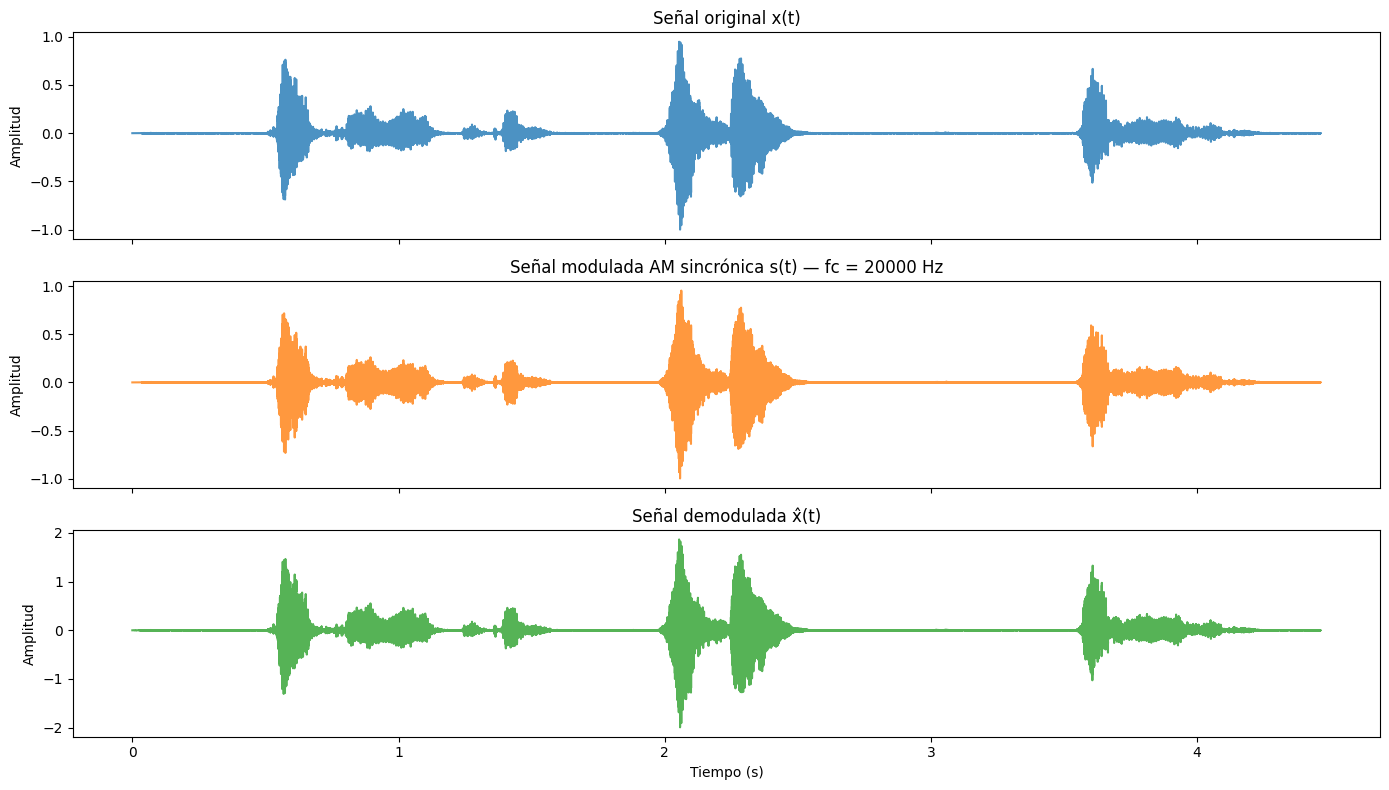

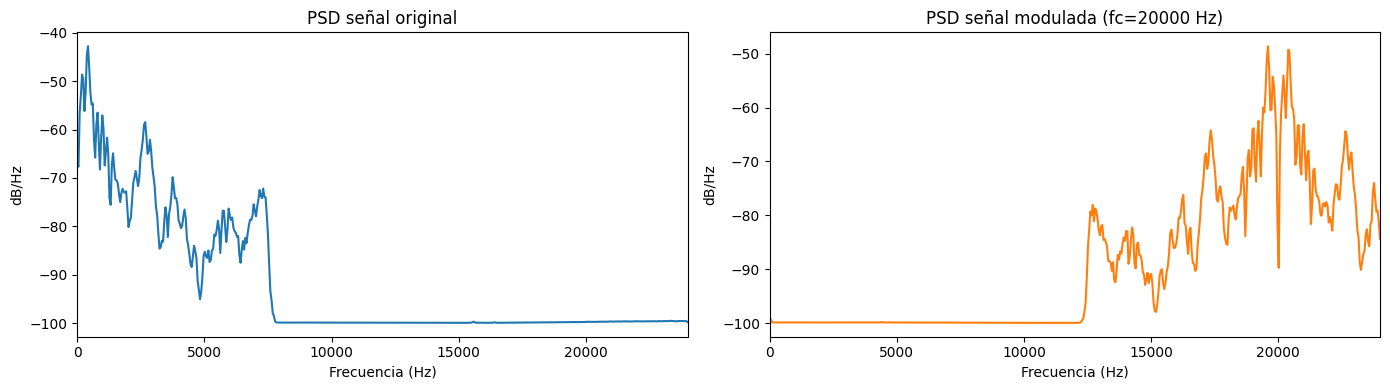

In [ ]:
def am_sincrona(x, fs, fc):
    t = np.arange(len(x)) / fs
    # Transmisor
    portadora = np.cos(2 * np.pi * fc * t)
    s_t = x * portadora
    # Receptor
    r_t = s_t * portadora
    # Filtro pasa bajos
    nyq = 0.5 * fs
    b, a = butter(5, fc * 0.8 / nyq, btype='low', analog=False)
    x_hat = filtfilt(b, a, r_t)
    x_hat = x_hat * 2.0  # compensación de ganancia
    return s_t, x_hat

# Normalizar señal antes de modular
x = complete_signal / np.max(np.abs(complete_signal))

# Portadora asignada 
fc = 20000  

s_t, x_hat = am_sincrona(x, sr, fc)
t = np.arange(len(x)) / sr

# Visualizar
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(t, x, alpha=0.8)
axes[0].set_title("Señal original x(t)")
axes[0].set_ylabel("Amplitud")

axes[1].plot(t, s_t, alpha=0.8, color='C1')
axes[1].set_title(f"Señal modulada AM sincrónica s(t) — fc = {fc} Hz")
axes[1].set_ylabel("Amplitud")

axes[2].plot(t, x_hat, alpha=0.8, color='C2')
axes[2].set_title("Señal demodulada x̂(t)")
axes[2].set_ylabel("Amplitud")
axes[2].set_xlabel("Tiempo (s)")

plt.tight_layout()
plt.show()

# Comparar espectros
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

f_orig, psd_orig = welch(x, fs=sr, nperseg=1024)
f_mod,  psd_mod  = welch(s_t, fs=sr, nperseg=1024)

axes[0].plot(f_orig, 10*np.log10(psd_orig + 1e-10))
axes[0].set_title("PSD señal original")
axes[0].set_xlabel("Frecuencia (Hz)")
axes[0].set_ylabel("dB/Hz")
axes[0].set_xlim(0, sr/2)

axes[1].plot(f_mod, 10*np.log10(psd_mod + 1e-10), color='C1')
axes[1].set_title(f"PSD señal modulada (fc={fc} Hz)")
axes[1].set_xlabel("Frecuencia (Hz)")
axes[1].set_ylabel("dB/Hz")
axes[1].set_xlim(0, sr/2)

plt.tight_layout()
plt.show()

# Escuchar
display(Audio(x_hat, rate=sr))

■ Modulaci´on Angular (FM / PM): El sistema debe poseer la capacidad de
conmutar el esquema de transmisi´on hacia una modulaci´on de tipo angular (Fre-
cuencia o Fase).

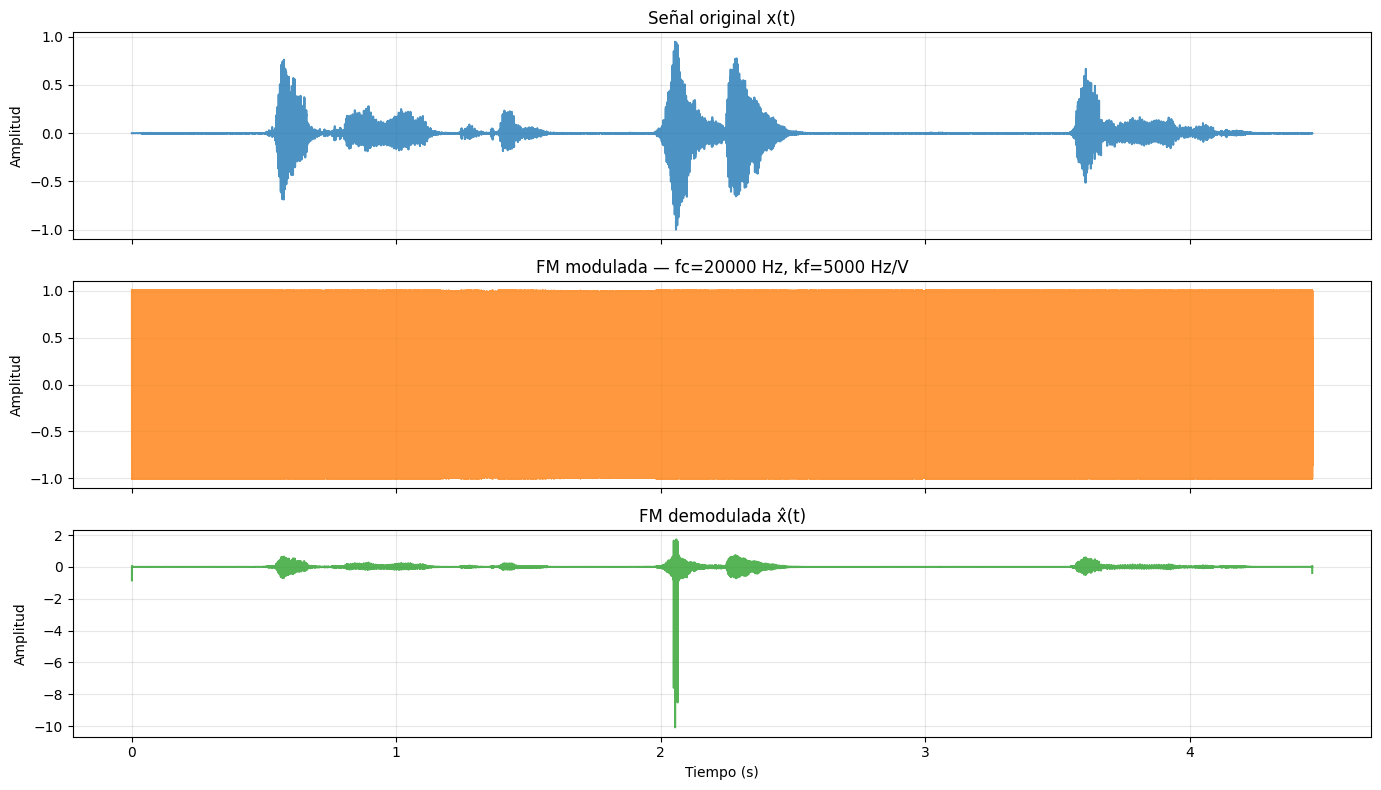

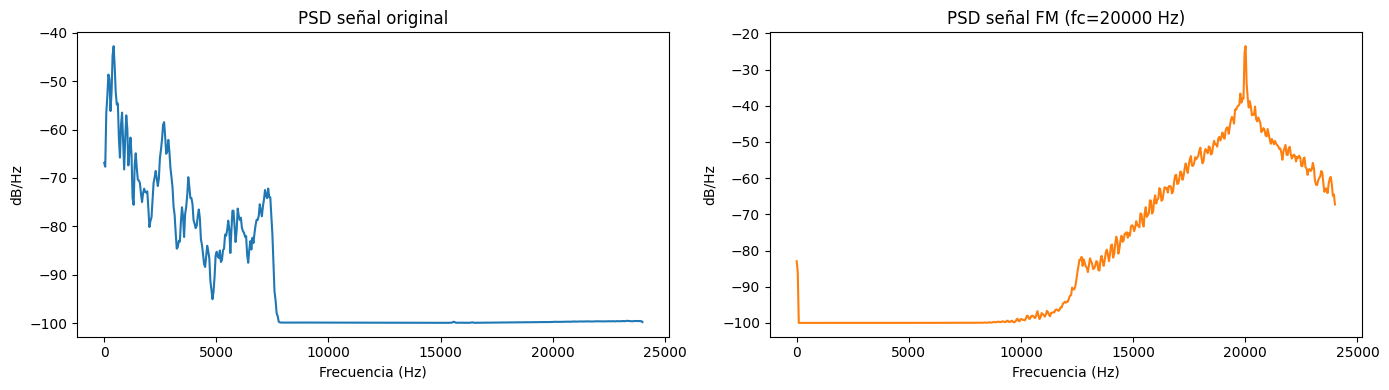

Potencia señal original: 0.0085
Potencia señal FM:       0.5000


In [30]:
def modulacion_fm(x, fs, fc, kf):
    t = np.arange(len(x)) / fs
    dt = 1 / fs
    integral_x = np.cumsum(x) * dt
    y = np.cos(2 * np.pi * fc * t + 2 * np.pi * kf * integral_x)
    return y

def demodular_fm(s_t, fs, fc, kf):
    from scipy.signal import hilbert
    analitica = hilbert(s_t)
    fase_inst = np.unwrap(np.angle(analitica))
    freq_inst = np.diff(fase_inst) * fs / (2 * np.pi)
    freq_inst = np.append(freq_inst, freq_inst[-1])
    x_hat = (freq_inst - fc) / kf
    nyq = 0.5 * fs
    b, a = butter(5, 8000 / nyq, btype='low')
    x_hat = filtfilt(b, a, x_hat)
    return x_hat

# Aplicar a la señal
x = complete_signal / np.max(np.abs(complete_signal))
fc = 20000
kf = 5000

s_fm = modulacion_fm(x, sr, fc, kf)
x_hat_fm = demodular_fm(s_fm, sr, fc, kf)

t = np.arange(len(x)) / sr

# Visualizar
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(t, x, alpha=0.8)
axes[0].set_title("Señal original x(t)")
axes[1].plot(t, s_fm, alpha=0.8, color='C1')
axes[1].set_title(f"FM modulada — fc={fc} Hz, kf={kf} Hz/V")
axes[2].plot(t, x_hat_fm, alpha=0.8, color='C2')
axes[2].set_title("FM demodulada x̂(t)")
for ax in axes:
    ax.set_ylabel("Amplitud")
    ax.grid(True, alpha=0.3)
axes[2].set_xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()

# Comparar espectros
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
f_orig, psd_orig = welch(x, fs=sr, nperseg=1024)
f_mod,  psd_mod  = welch(s_fm, fs=sr, nperseg=1024)
axes[0].plot(f_orig, 10*np.log10(psd_orig + 1e-10))
axes[0].set_title("PSD señal original")
axes[0].set_xlabel("Frecuencia (Hz)")
axes[0].set_ylabel("dB/Hz")
axes[1].plot(f_mod, 10*np.log10(psd_mod + 1e-10), color='C1')
axes[1].set_title(f"PSD señal FM (fc={fc} Hz)")
axes[1].set_xlabel("Frecuencia (Hz)")
axes[1].set_ylabel("dB/Hz")
plt.tight_layout()
plt.show()

# Potencia (propiedad clave de FM del TP anterior)
print(f"Potencia señal original: {np.mean(x**2):.4f}")
print(f"Potencia señal FM:       {np.mean(s_fm**2):.4f}")

display(Audio(x_hat_fm, rate=sr))

■ An´alisis de Potencia y Ancho de Banda: Para ambos esquemas de modulaci´on
(AM y FM/PM), calcular, simular y comparar el ancho de banda total requerido
en el canal (aplicando, por ejemplo, la regla de Carson para el caso de FM) y la
eficiencia de potencia de la se˜nal transmitida.

BW AM (DSB-SC): 16000 Hz
Desviación de frecuencia Δf: 5000.0 Hz
Índice de modulación β: 0.62
BW FM (Carson): 26000.0 Hz

Potencia señal original:  0.0085 W
Potencia señal AM:        0.0042 W
Potencia señal FM:        0.5000 W

Eficiencia AM (DSB-SC):  199.9%
Eficiencia FM:           100.0%

Criterio                       AM (DSB-SC)         FM
Ancho de banda (Hz)                 16000    26000.0
Δf / β                                  —   5000/0.6
Potencia transmitida (W)           0.0042     0.5000
Eficiencia de potencia             199.9%     100.0%
Potencia constante                     No         Sí
Complejidad demodulador              Baja      Media


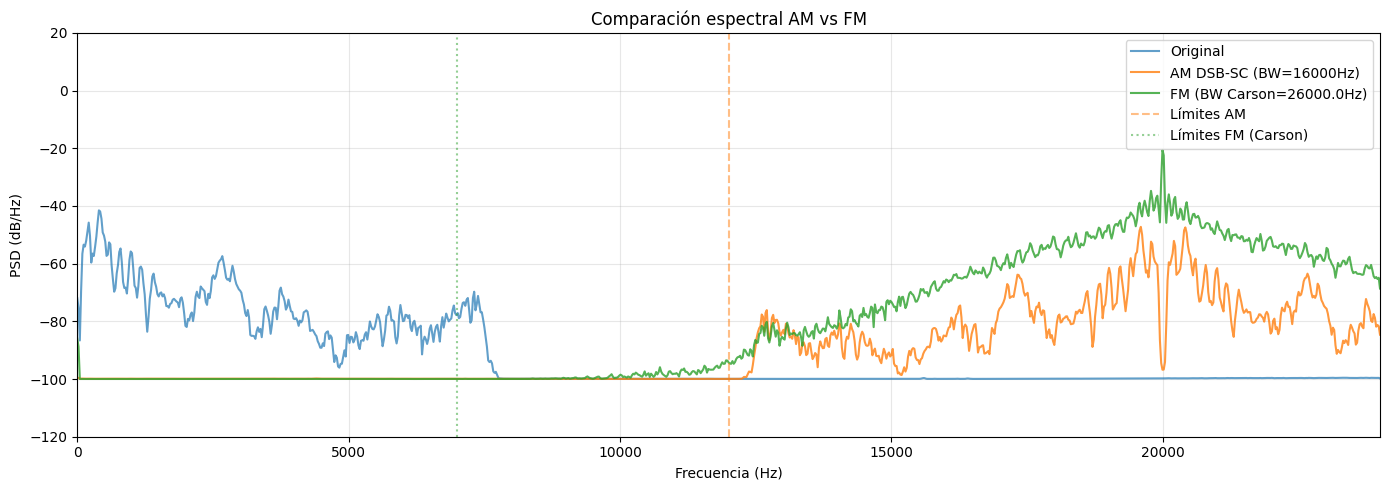

In [31]:
# =============================================
# ANCHO DE BANDA
# =============================================

# Ancho de banda de la señal mensaje (ya filtrada a 8kHz)
BW_mensaje = 8000  # Hz

# --- AM Sincrónica (DSB-SC) ---
# El espectro se traslada a ±fc, por lo que ocupa el doble del ancho de banda
BW_AM = 2 * BW_mensaje
print(f"BW AM (DSB-SC): {BW_AM} Hz")

# --- FM: Regla de Carson ---
# BW_FM = 2 * (Δf + BW_mensaje)
# donde Δf = kf * max(|x(t)|) = desviación máxima de frecuencia
delta_f = kf * np.max(np.abs(x))  # x ya está normalizado → delta_f = kf
beta = delta_f / BW_mensaje        # índice de modulación
BW_FM = 2 * (delta_f + BW_mensaje)
print(f"Desviación de frecuencia Δf: {delta_f:.1f} Hz")
print(f"Índice de modulación β: {beta:.2f}")
print(f"BW FM (Carson): {BW_FM} Hz")

# =============================================
# EFICIENCIA DE POTENCIA
# =============================================

# Potencias
P_original = np.mean(x**2)
P_AM  = np.mean(s_t**2)    # s_t de la modulación AM anterior
P_FM  = np.mean(s_fm**2)

print(f"\nPotencia señal original:  {P_original:.4f} W")
print(f"Potencia señal AM:        {P_AM:.4f} W")
print(f"Potencia señal FM:        {P_FM:.4f} W")

# Eficiencia AM DSB-SC: toda la potencia va al mensaje (no hay portadora)
# η = P_mensaje / P_total
eta_AM = P_original / P_AM if P_AM > 0 else 0
eta_FM = 1.0  # FM siempre tiene potencia constante → eficiencia = 100%

print(f"\nEficiencia AM (DSB-SC):  {eta_AM*100:.1f}%")
print(f"Eficiencia FM:           {eta_FM*100:.1f}%")

# =============================================
# TABLA COMPARATIVA
# =============================================
print("\n" + "="*55)
print(f"{'Criterio':<30} {'AM (DSB-SC)':>10} {'FM':>10}")
print("="*55)
print(f"{'Ancho de banda (Hz)':<30} {BW_AM:>10} {BW_FM:>10}")
print(f"{'Δf / β':<30} {'—':>10} {f'{delta_f:.0f}/{beta:.1f}':>10}")
print(f"{'Potencia transmitida (W)':<30} {P_AM:>10.4f} {P_FM:>10.4f}")
print(f"{'Eficiencia de potencia':<30} {f'{eta_AM*100:.1f}%':>10} {f'{eta_FM*100:.1f}%':>10}")
print(f"{'Potencia constante':<30} {'No':>10} {'Sí':>10}")
print(f"{'Complejidad demodulador':<30} {'Baja':>10} {'Media':>10}")
print("="*55)

# =============================================
# VISUALIZAR ESPECTROS COMPARADOS
# =============================================
f_AM,  psd_AM  = welch(s_t,  fs=sr, nperseg=2048)
f_FM,  psd_FM  = welch(s_fm, fs=sr, nperseg=2048)
f_orig, psd_orig = welch(x,  fs=sr, nperseg=2048)

plt.figure(figsize=(14, 5))
plt.plot(f_orig, 10*np.log10(psd_orig + 1e-10), label='Original', alpha=0.7)
plt.plot(f_AM,   10*np.log10(psd_AM   + 1e-10), label=f'AM DSB-SC (BW={BW_AM}Hz)', alpha=0.8)
plt.plot(f_FM,   10*np.log10(psd_FM   + 1e-10), label=f'FM (BW Carson={BW_FM}Hz)', alpha=0.8)
plt.axvline(fc - BW_mensaje, color='C1', linestyle='--', alpha=0.5, label='Límites AM')
plt.axvline(fc + BW_mensaje, color='C1', linestyle='--', alpha=0.5)
plt.axvline(fc - delta_f - BW_mensaje, color='C2', linestyle=':', alpha=0.5, label='Límites FM (Carson)')
plt.axvline(fc + delta_f + BW_mensaje, color='C2', linestyle=':', alpha=0.5)
plt.xlim(0, sr/2)
plt.ylim(-120, 20)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD (dB/Hz)")
plt.title("Comparación espectral AM vs FM")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

2.5.1. Desaf´ıo de Evaluaci´on
El grupo de trabajo deber´a evaluar de forma comparativa y cr´ıtica ambos escenarios
utilizando m´etricas de ingenier´ıa. Los resultados e hip´otesis deben resumirse cualitativa
o cuantitativamente bajo la estructura del Cuadro 1.

Cuadro 1: Matriz comparativa de eficiencia de transmisi´on (Escenario A vs. Escenario
B)

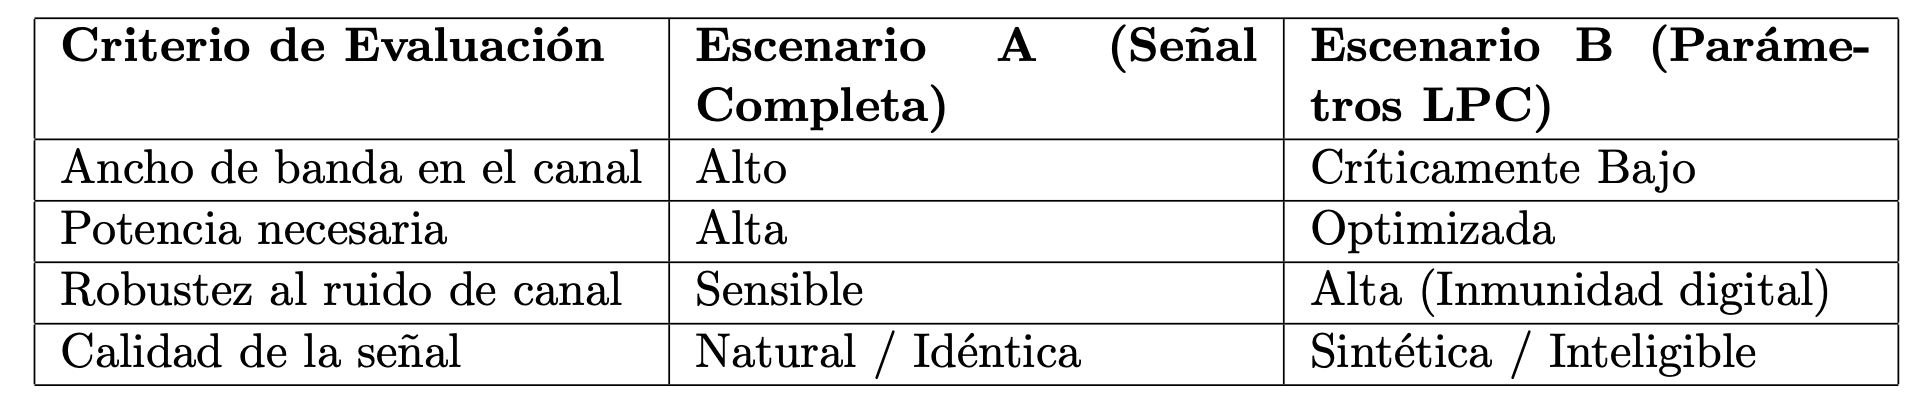

Los alumnos concluir´an el informe realizando una defensa cr´ıtica sobre cu´al escenario
elegir´ıan para desplegar en sistemas con restricciones severas de ancho de banda (como
telefon´ıa m´ovil o satelital), contrast´andolo con entornos donde se priorice la fidelidad
absoluta del audio.

In [32]:
# =============================================
# ESCENARIO A: Señal filtrada + AM
# =============================================

# Usamos signal_fir (ya filtrada en Etapa II)
x_A = signal_fir / np.max(np.abs(signal_fir))
s_A, x_hat_A = am_sincrona(x_A, sr, fc)

# Bits necesarios para transmitir (cuantización a 16 bits, como el WAV original)
bits_por_muestra = 16
muestras_A = len(x_A)
bits_totales_A = muestras_A * bits_por_muestra
duracion = len(x_A) / sr

tasa_bits_A = bits_totales_A / duracion  # bps
BW_necesario_A = BW_AM  # ya calculado

P_A = np.mean(s_A**2)

print("=" * 50)
print("ESCENARIO A: Señal completa + AM")
print("=" * 50)
print(f"Duración señal:         {duracion:.2f} s")
print(f"Muestras a transmitir:  {muestras_A}")
print(f"Bits totales:           {bits_totales_A / 1e6:.2f} Mbits")
print(f"Tasa de bits:           {tasa_bits_A / 1e3:.1f} kbps")
print(f"Ancho de banda canal:   {BW_necesario_A} Hz")
print(f"Potencia transmitida:   {P_A:.4f} W")

# =============================================
# ESCENARIO B: Parámetros LPC
# =============================================

# Estructura del frame: [a1..a14, G, Bs/s, T0] = 17 valores float (32 bits c/u)
n_frames = len(matriz_transmision)
valores_por_frame = p_max + 3   # 14 coefs + G + Bs/s + T0
bits_por_valor = 32             # float32
bits_totales_B = n_frames * valores_por_frame * bits_por_valor

tasa_bits_B = bits_totales_B / duracion
BW_necesario_B = tasa_bits_B / 2  # Nyquist: BW mínimo = tasa/2

P_B = np.mean(s_fm**2)  # FM de los parámetros → potencia constante

print("\n" + "=" * 50)
print("ESCENARIO B: Parámetros LPC + FM")
print("=" * 50)
print(f"Frames transmitidos:    {n_frames}")
print(f"Valores por frame:      {valores_por_frame}")
print(f"Bits totales:           {bits_totales_B / 1e3:.2f} kbits")
print(f"Tasa de bits:           {tasa_bits_B:.1f} bps")
print(f"Ancho de banda canal:   {BW_necesario_B:.1f} Hz")
print(f"Potencia transmitida:   {P_B:.4f} W")

# =============================================
# MÉTRICAS DE CALIDAD
# =============================================

# SNR de reconstrucción (Escenario A)
error_A = x_A[:len(x_hat_A)] - x_hat_A
SNR_A = 10 * np.log10(np.mean(x_A**2) / (np.mean(error_A**2) + 1e-10))

# SNR de reconstrucción (Escenario B)
x_B = senal_reconstruida / (np.max(np.abs(senal_reconstruida)) + 1e-10)
largo = min(len(x_A), len(x_B))
error_B = x_A[:largo] - x_B[:largo]
SNR_B = 10 * np.log10(np.mean(x_A[:largo]**2) / (np.mean(error_B**2) + 1e-10))

# Factor de compresión
factor_compresion = bits_totales_A / bits_totales_B

print("\n" + "=" * 50)
print("COMPARACIÓN")
print("=" * 50)
print(f"SNR Escenario A:        {SNR_A:.2f} dB")
print(f"SNR Escenario B:        {SNR_B:.2f} dB")
print(f"Factor de compresión:   {factor_compresion:.1f}x  (B es {factor_compresion:.0f} veces más liviano)")
print(f"Reducción de BW:        {(1 - BW_necesario_B/BW_necesario_A)*100:.1f}%")

# =============================================
# TABLA COMPARATIVA FINAL
# =============================================
print("\n" + "=" * 65)
print(f"{'Criterio':<32} {'Escenario A':>14} {'Escenario B':>14}")
print("=" * 65)
print(f"{'Bits transmitidos':<32} {f'{bits_totales_A/1e6:.2f} Mbits':>14} {f'{bits_totales_B/1e3:.1f} kbits':>14}")
print(f"{'Tasa de bits (kbps)':<32} {f'{tasa_bits_A/1e3:.1f}':>14} {f'{tasa_bits_B:.1f}':>14}")
print(f"{'Ancho de banda (Hz)':<32} {f'{BW_necesario_A}':>14} {f'{BW_necesario_B:.1f}':>14}")
print(f"{'Potencia transmitida (W)':<32} {f'{P_A:.4f}':>14} {f'{P_B:.4f}':>14}")
print(f"{'SNR reconstrucción (dB)':<32} {f'{SNR_A:.2f}':>14} {f'{SNR_B:.2f}':>14}")
print(f"{'Factor de compresión':<32} {'1x (referencia)':>14} {f'{factor_compresion:.0f}x':>14}")
print(f"{'Calidad perceptual':<32} {'Natural':>14} {'Inteligible':>14}")
print(f"{'Robustez al ruido':<32} {'Sensible':>14} {'Alta':>14}")
print("=" * 65)

# Escuchar ambos para comparar perceptualmente
print("\nEscenario A (señal filtrada):")
display(Audio(x_hat_A, rate=sr))
print("Escenario B (reconstrucción LPC):")
display(Audio(senal_reconstruida, rate=sr))

ESCENARIO A: Señal completa + AM
Duración señal:         4.46 s
Muestras a transmitir:  214272
Bits totales:           3.43 Mbits
Tasa de bits:           768.0 kbps
Ancho de banda canal:   16000 Hz
Potencia transmitida:   0.0042 W

ESCENARIO B: Parámetros LPC + FM
Frames transmitidos:    148
Valores por frame:      103
Bits totales:           487.81 kbits
Tasa de bits:           109276.0 bps
Ancho de banda canal:   54638.0 Hz
Potencia transmitida:   0.5000 W

COMPARACIÓN
SNR Escenario A:        3.01 dB
SNR Escenario B:        -2.68 dB
Factor de compresión:   7.0x  (B es 7 veces más liviano)
Reducción de BW:        -241.5%

Criterio                            Escenario A    Escenario B
Bits transmitidos                    3.43 Mbits    487.8 kbits
Tasa de bits (kbps)                       768.0       109276.0
Ancho de banda (Hz)                       16000        54638.0
Potencia transmitida (W)                 0.0042         0.5000
SNR reconstrucción (dB)                    3.01       

Escenario B (reconstrucción LPC):
